In [88]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from scipy.spatial import cKDTree

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Incarcare date

In [89]:
df = pd.read_csv("pmb_dosare2.csv", low_memory=False)
df["are_pdf"] = df["Pdf_nume"].notna()

print("Shape initial:", df.shape)
display(df.head(3))

Shape initial: (47077, 28)


,Dosar PMB,Solicitant,Notificare PMB,Adresa contemporană,Adresa istorică,Tip proprietate,Soluție,Istorie acte,Mai multe adrese,lat,lon,Solutie_string,Solutie_grup,Pdf_nume,Pdf_valid,An_solutie,Persoana_fizica,fragmente,LEGE,Executor,NATIONALIZARE_nr,NATIONALIZARE_text,Contract_chirie,Fragment_contract,Categorie_proprietate,An_depunere,sector,are_pdf
0,1 / 2001-02-19,LERESCU MAGDALENA VERONICA,847 / 2001-02-15,"STR. CARAGEA IOAN VODA , nr.: 9-15, sector: 1,",Strada Caragia Vodă,Imobil,"DPG: 12494, Dată: 2010-02-15, Restituire in na...",DPG: 1 Dată: 2001-06-20 Restituire in natura,DA,44.449382,26.100929,Restituire in natura,Restituire,1_1_2001-06-20.pdf,True,2010.0,True,NaN,NaN,True,NaN,NaN,1_1_2001-06-20.pdf,Contractele de inchiriere dintre chiriasi si D...,Constructie + Teren,2001.0,1.0,True
1,1 / 2001-02-19,LERESCU MAGDALENA VERONICA,847 / 2001-02-15,"STR. PARIS, nr.: 4, sector: 1,",NONE,Imobil,"DPG: 12494, Dată: 2010-02-15, Restituire in na...",DPG: 1 Dată: 2001-06-20 Restituire in natura,DA,44.453716,26.087536,Restituire in natura,Restituire,1_1_2001-06-20.pdf,True,2010.0,True,NaN,NaN,True,NaN,NaN,1_1_2001-06-20.pdf,Contractele de inchiriere dintre chiriasi si D...,Constructie + Teren,2001.0,1.0,True
2,2 / 2001-02-23,BOCANCEA DRAGOS VASILE; BOCANCEA ANGELA,620 / 2001-02-21,"STR. EREMIA GRIGORESCU ap.parter , nr.: 18, se...",Strada Armașului,Imobil,"DPG: 18063, Dată: 2014-06-12, Masuri Reparatorii",NONE,NU,44.445117,26.101591,Masuri Reparatorii,Compensare/Despagubiri,NaN,False,2014.0,True,NaN,NaN,False,NaN,NaN,NaN,NaN,Imobil,2001.0,1.0,False


In [90]:
def count_dispozitii(istorie_str):
    if pd.isna(istorie_str) or str(istorie_str).strip() in ["NONE", ""]:
        return 0
    entries = [e.strip() for e in str(istorie_str).split(";") if e.strip()]
    return len(entries)

def get_last_dpg(solutie_str):
    if pd.isna(solutie_str):
        return None
    match = re.search(r"DPG:\s*(\d+)", str(solutie_str))
    return match.group(1) if match else None

def get_dpg_from_pdf(pdf_name):
    if pd.isna(pdf_name):
        return None
    match = re.search(r"_(\d+)_\d{4}-\d{2}-\d{2}\.pdf", str(pdf_name))
    return match.group(1) if match else None

CENTRU_LAT = 44.4328
CENTRU_LON = 26.1043

def haversine_km(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan

    R = 6371.0

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [91]:
df["nr_dispozitii"] = df["Istorie acte"].apply(count_dispozitii)

df["last_dpg"] = df["Soluție"].apply(get_last_dpg)
df["are_chiriasi"] = df["Contract_chirie"].notna()
df["chirie_dpg"] = df["Contract_chirie"].apply(get_dpg_from_pdf)

df["chirisi_leaky"] = df.apply(
    lambda r: r["are_chiriasi"] and (r["chirie_dpg"] == r["last_dpg"]),
    axis=1
)

df["are_chiriasi_curat"] = df["are_chiriasi"] & ~df["chirisi_leaky"]

df["dist_km_centru"] = df.apply(
    lambda r: haversine_km(r["lat"], r["lon"], CENTRU_LAT, CENTRU_LON),
    axis=1
)

radial_bins = [0, 1, 2, 4, 6, 8, np.inf]
radial_labels = ["0-1km", "1-2km", "2-4km", "4-6km", "6-8km", "8km+"]
df["dist_bin_km"] = pd.cut(
    df["dist_km_centru"],
    bins=radial_bins,
    labels=radial_labels,
    include_lowest=True,
    right=False
)

print("Distributie nr_dispozitii:")
print(df["nr_dispozitii"].describe())

print("\nLeakage chiriasi:")
print(f"{df['chirisi_leaky'].sum()} leaky din {df['are_chiriasi'].sum()} total cu chiriasi")

# top legi pe care vrem sa le pastram explicit
legi_selectate = [
    "Decret 92/1950",
    "Decret 223/1974",
    "Decret 111/1951",
    "Lege 58/1974",
    "Lege 4/1973",
    "Decret 224/1951",
    "Decret 112/1989",
    "Decret 218/1960",
    "Decret 152/1980",
    "HG 556/1990"
]

df["LEGE_top"] = df["LEGE"].where(df["LEGE"].isin(legi_selectate), "ALTELE")
df["LEGE_top"] = df["LEGE_top"].fillna("NECUNOSCUT")

df["Executor_clean"] = df["Executor"].fillna(False).astype(str)

Distributie nr_dispozitii:
count    47077.000000
mean         0.281645
std          0.826101
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         16.000000
Name: nr_dispozitii, dtype: float64

Leakage chiriasi:
681 leaky din 1220 total cu chiriasi


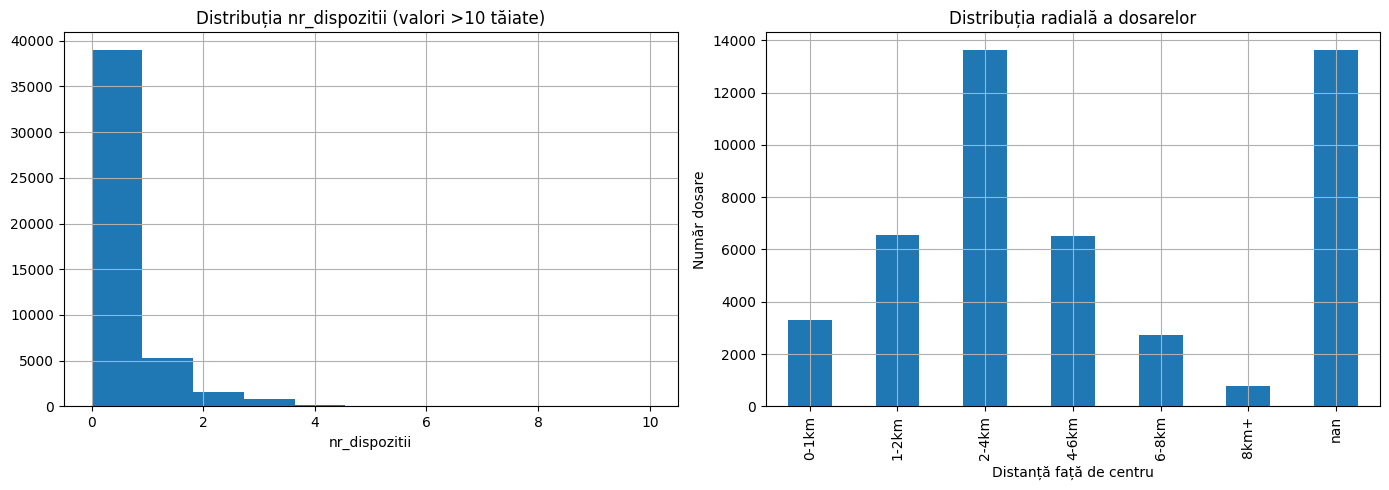

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["nr_dispozitii"].clip(upper=10).hist(ax=axes[0], bins=11)
axes[0].set_title("Distribuția nr_dispozitii (valori >10 tăiate)")
axes[0].set_xlabel("nr_dispozitii")

df["dist_bin_km"].value_counts(dropna=False).sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Distribuția radială a dosarelor")
axes[1].set_xlabel("Distanță față de centru")
axes[1].set_ylabel("Număr dosare")

plt.tight_layout()
plt.show()

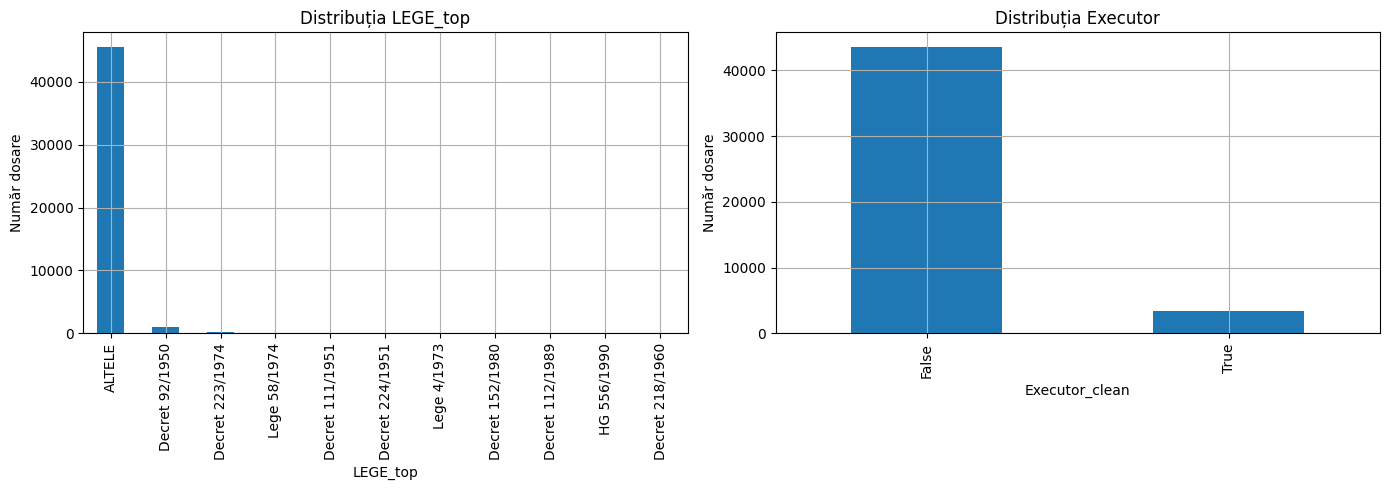

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["LEGE_top"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribuția LEGE_top")
axes[0].set_xlabel("LEGE_top")
axes[0].set_ylabel("Număr dosare")

df["Executor_clean"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Distribuția Executor")
axes[1].set_xlabel("Executor_clean")
axes[1].set_ylabel("Număr dosare")

plt.tight_layout()
plt.show()

## Downsampling

In [94]:
clase_ok = ["Compensare/Despagubiri", "Respins/Negativ", "Restituire"]

df3 = df[df["Solutie_grup"].isin(clase_ok)].copy()
df3 = df3[df3["lat"].notna() & df3["lon"].notna()].copy()

comp = df3[df3["Solutie_grup"] == "Compensare/Despagubiri"]
comp_cu_pdf = comp[comp["are_pdf"] == True]
comp_fara_pdf = comp[comp["are_pdf"] == False]

n_target = 4000
n_extra = n_target - len(comp_cu_pdf)

if n_extra > 0:
    comp_sample = pd.concat([
        comp_cu_pdf,
        comp_fara_pdf.sample(n=min(n_extra, len(comp_fara_pdf)), random_state=42)
    ])
else:
    comp_sample = comp_cu_pdf.sample(n=n_target, random_state=42)

df_model = pd.concat([
    df3[df3["Solutie_grup"] != "Compensare/Despagubiri"],
    comp_sample
]).reset_index(drop=True)

print("Distributie clase dupa downsampling:")
print(df_model["Solutie_grup"].value_counts())

Distributie clase dupa downsampling:
Solutie_grup
Compensare/Despagubiri    4000
Respins/Negativ           3826
Restituire                2908
Name: count, dtype: int64


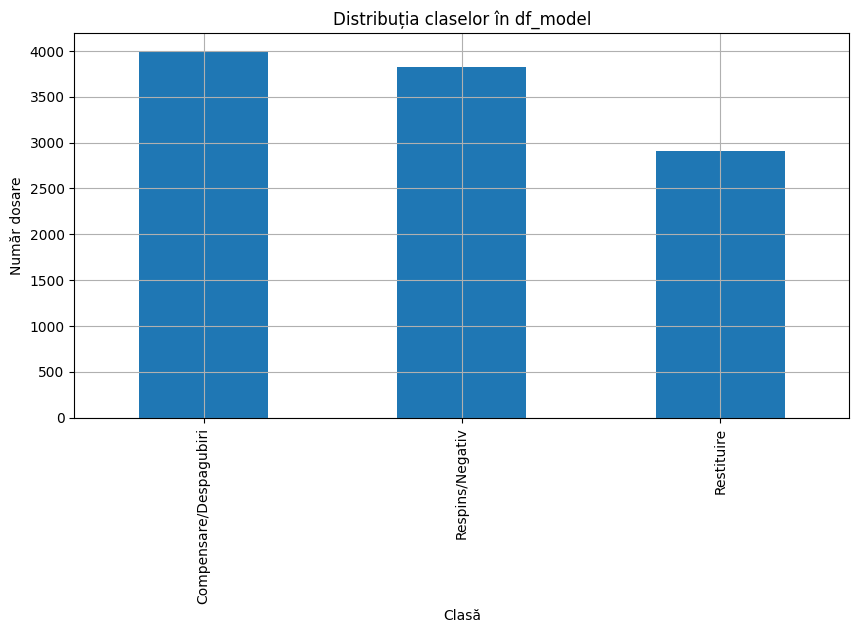

In [95]:
df_model["Solutie_grup"].value_counts().plot(kind="bar")
plt.title("Distribuția claselor în df_model")
plt.xlabel("Clasă")
plt.ylabel("Număr dosare")
plt.show()

## Date Storia

Storia total curat: 18706
Storia vanzare: 11638
Storia chirie: 7068


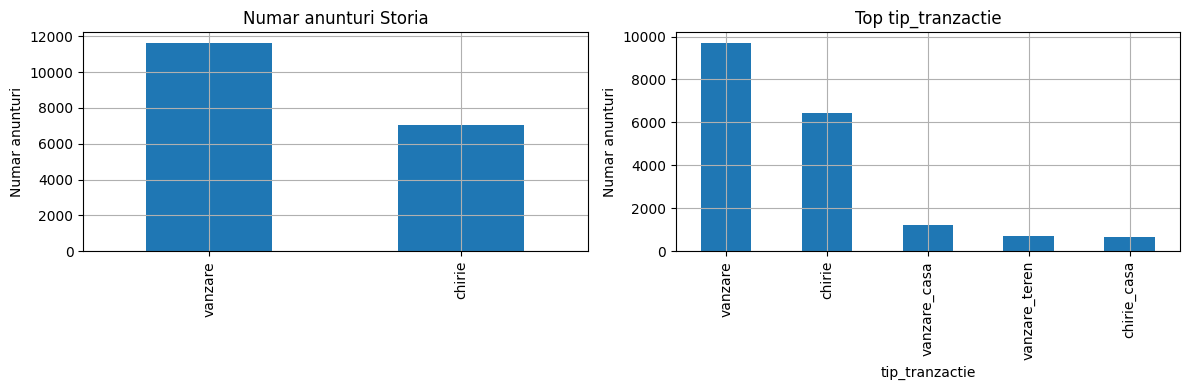

In [96]:
storia = pd.read_csv("storia_anunturi.csv")

storia_curat = storia[
    (storia["pret_mp"] > 0) &
    (storia["pret_mp"] <= 10000) &
    storia["lat"].notna() &
    storia["long"].notna()
].copy()

storia_vanzare = storia_curat[
    storia_curat["tip_tranzactie"].isin(["vanzare", "vanzare_casa", "vanzare_teren"])
].copy()

storia_chirie = storia_curat[
    storia_curat["tip_tranzactie"].isin(["chirie", "chirie_casa"])
].copy()

print("Storia total curat:", len(storia_curat))
print("Storia vanzare:", len(storia_vanzare))
print("Storia chirie:", len(storia_chirie))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series({
    "vanzare": len(storia_vanzare),
    "chirie": len(storia_chirie)
}).plot(kind="bar", ax=axes[0])
axes[0].set_title("Numar anunturi Storia")
axes[0].set_ylabel("Numar anunturi")

storia_curat["tip_tranzactie"].value_counts().head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top tip_tranzactie")
axes[1].set_ylabel("Numar anunturi")

plt.tight_layout()
plt.show()

In [97]:
RAZA = 0.010  # aproximativ 1.1 km

tree_vanzare = cKDTree(storia_vanzare[["lat", "long"]].values)
tree_chirie = cKDTree(storia_chirie[["lat", "long"]].values)

def get_median(tree, df_storia, lat, lon, raza=RAZA):
    idx = tree.query_ball_point([lat, lon], raza)
    if idx:
        return df_storia.iloc[idx]["pret_mp"].median()
    return np.nan

def get_count(tree, lat, lon, raza=RAZA):
    return len(tree.query_ball_point([lat, lon], raza))

print("Calculez preturi zonale...")

df_model["pret_vanzare_zona"] = df_model.apply(
    lambda r: get_median(tree_vanzare, storia_vanzare, r["lat"], r["lon"]),
    axis=1
)

df_model["pret_chirie_zona"] = df_model.apply(
    lambda r: get_median(tree_chirie, storia_chirie, r["lat"], r["lon"]),
    axis=1
)

df_model["nr_anunturi_vanzare_zona"] = df_model.apply(
    lambda r: get_count(tree_vanzare, r["lat"], r["lon"]),
    axis=1
)

df_model["nr_anunturi_chirie_zona"] = df_model.apply(
    lambda r: get_count(tree_chirie, r["lat"], r["lon"]),
    axis=1
)


print("Acoperire pret_vanzare_zona:", df_model["pret_vanzare_zona"].notna().sum(), "/", len(df_model))
print("Acoperire pret_chirie_zona:", df_model["pret_chirie_zona"].notna().sum(), "/", len(df_model))

Calculez preturi zonale...
Acoperire pret_vanzare_zona: 10722 / 10734
Acoperire pret_chirie_zona: 10708 / 10734


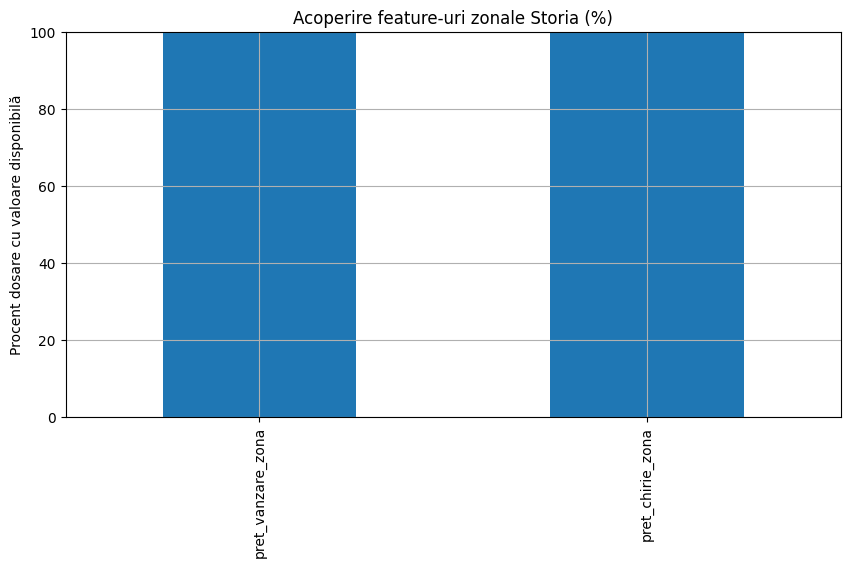

In [98]:
coverage = pd.Series({
    "pret_vanzare_zona": df_model["pret_vanzare_zona"].notna().mean(),
    "pret_chirie_zona": df_model["pret_chirie_zona"].notna().mean()
}) * 100

coverage.plot(kind="bar")
plt.title("Acoperire feature-uri zonale Storia (%)")
plt.ylabel("Procent dosare cu valoare disponibilă")
plt.ylim(0, 100)
plt.show()

In [99]:
media_globala_vanzare = storia_vanzare["pret_mp"].median()
media_globala_chirie  = storia_chirie["pret_mp"].median()

df_model["pret_vanzare_relativ"] = df_model["pret_vanzare_zona"] / media_globala_vanzare
df_model["pret_chirie_relativ"]  = df_model["pret_chirie_zona"] / media_globala_chirie

# FOARTE IMPORTANT
df_model["has_chirie"] = df_model["pret_chirie_zona"].notna().astype(int)

print("Mediana globala vanzare:", round(media_globala_vanzare, 2))
print("Mediana globala chirie:", round(media_globala_chirie, 2))

Mediana globala vanzare: 1970.3
Mediana globala chirie: 11.0


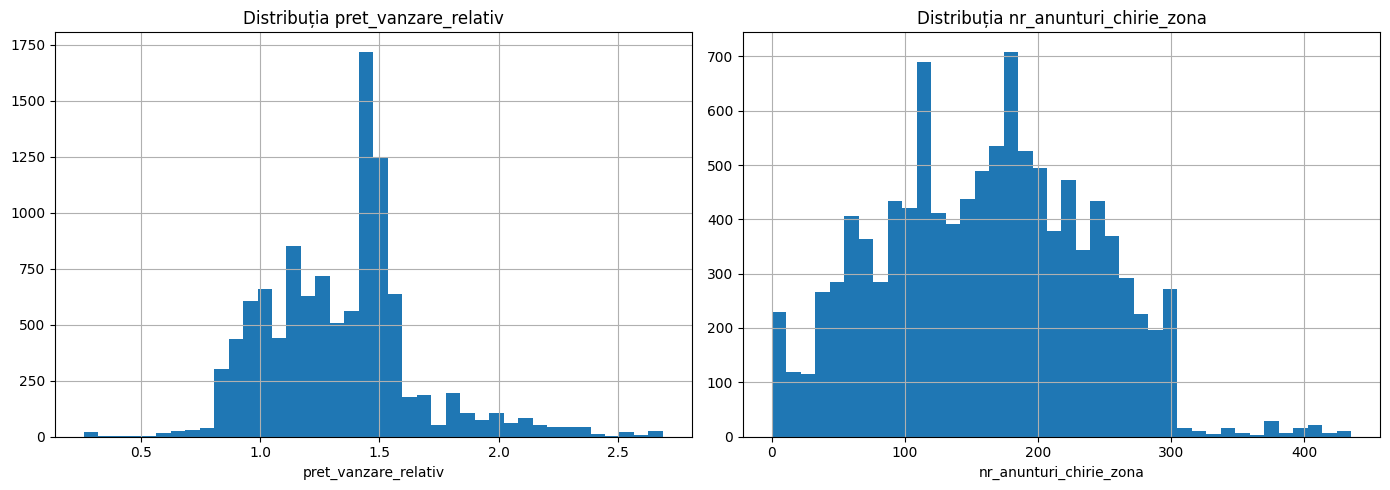

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_model["pret_vanzare_relativ"].dropna().hist(ax=axes[0], bins=40)
axes[0].set_title("Distribuția pret_vanzare_relativ")
axes[0].set_xlabel("pret_vanzare_relativ")

df_model["nr_anunturi_chirie_zona"].hist(ax=axes[1], bins=40)
axes[1].set_title("Distribuția nr_anunturi_chirie_zona")
axes[1].set_xlabel("nr_anunturi_chirie_zona")

plt.tight_layout()
plt.show()

In [101]:
class_price_summary = df_model.groupby("Solutie_grup")[[
    "pret_vanzare_relativ",
    "nr_anunturi_vanzare_zona",
    "nr_anunturi_chirie_zona"
]].median().round(3)

display(class_price_summary)

,pret_vanzare_relativ,nr_anunturi_vanzare_zona,nr_anunturi_chirie_zona
Solutie_grup,,,
Compensare/Despagubiri,1.340,167.0,167.0
Respins/Negativ,1.379,158.0,158.0
Restituire,1.387,163.0,168.0


## Train test split

In [102]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(
    gss.split(df_model, df_model["Solutie_grup"], groups=df_model["Solicitant"])
)

train_df = df_model.iloc[train_idx].copy()
test_df = df_model.iloc[test_idx].copy()

print("Train:", len(train_df))
print(train_df["Solutie_grup"].value_counts(normalize=True).round(3))

print("\nTest:", len(test_df))
print(test_df["Solutie_grup"].value_counts(normalize=True).round(3))

print("\nOverlap solicitanti:", len(set(train_df["Solicitant"]) & set(test_df["Solicitant"])))

Train: 8466
Solutie_grup
Compensare/Despagubiri    0.381
Respins/Negativ           0.343
Restituire                0.276
Name: proportion, dtype: float64

Test: 2268
Solutie_grup
Respins/Negativ           0.408
Compensare/Despagubiri    0.341
Restituire                0.251
Name: proportion, dtype: float64

Overlap solicitanti: 0


In [103]:
cat_cols_base = [
    "Tip proprietate",
    "Persoana_fizica",
    "Mai multe adrese",
    "are_pdf",
    "sector",
    "LEGE_top",
    "Executor_clean",
]
num_cols_base = [
    "An_depunere",
    "lat",
    "lon",
    "dist_km_centru",
    "nr_dispozitii",
]

def train_and_evaluate(train_df, test_df, cat_cols, num_cols, model_name):
    train_local = train_df.copy()
    test_local = test_df.copy()

    for c in cat_cols:
        train_local[c] = train_local[c].astype("object").where(train_local[c].notna(), "NECUNOSCUT").astype(str)
        test_local[c] = test_local[c].astype("object").where(test_local[c].notna(), "NECUNOSCUT").astype(str)

    train_enc = pd.get_dummies(
        train_local[cat_cols + num_cols + ["Solutie_grup"]],
        columns=cat_cols
    )
    test_enc = pd.get_dummies(
        test_local[cat_cols + num_cols + ["Solutie_grup"]],
        columns=cat_cols
    )

    train_enc, test_enc = train_enc.align(test_enc, join="left", axis=1, fill_value=0)

    feature_cols = [c for c in train_enc.columns if c != "Solutie_grup"]

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(train_enc[feature_cols])
    X_test = imputer.transform(test_enc[feature_cols])

    y_train = train_local["Solutie_grup"].values
    y_test = test_local["Solutie_grup"].values

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

    result = {
        "model_name": model_name,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "report": classification_report(y_test, y_pred),
        "importances": importances,
        "rf": rf,
        "X_test": X_test,
        "y_test": y_test,
        "feature_cols": feature_cols
    }
    return result

## Model fara Storia

In [104]:
res_base = train_and_evaluate(
    train_df=train_df,
    test_df=test_df,
    cat_cols=cat_cols_base,
    num_cols=num_cols_base,
    model_name="baseline"
)

print(res_base["report"])
print("\nTop 15 features baseline:")
display(res_base["importances"].head(15))

                        precision    recall  f1-score   support

Compensare/Despagubiri       0.56      0.65      0.60       774
       Respins/Negativ       0.68      0.61      0.64       925
            Restituire       0.54      0.51      0.53       569

              accuracy                           0.60      2268
             macro avg       0.59      0.59      0.59      2268
          weighted avg       0.60      0.60      0.60      2268


Top 15 features baseline:


lat                        0.226931
dist_km_centru             0.226382
lon                        0.224132
nr_dispozitii              0.083395
An_depunere                0.046165
LEGE_top_ALTELE            0.020368
Persoana_fizica_False      0.019289
Persoana_fizica_True       0.018706
Tip proprietate_Teren      0.011094
Tip proprietate_Imobil     0.010636
Mai multe adrese_NU        0.009659
LEGE_top_Decret 92/1950    0.009475
Mai multe adrese_DA        0.009402
sector_1.0                 0.008609
sector_2.0                 0.008073
dtype: float64

## Model cu Storia

In [105]:
res_both = train_and_evaluate(
    train_df=train_df,
    test_df=test_df,
    cat_cols=cat_cols_base,
    num_cols=num_cols_base + [
        "pret_vanzare_relativ",
        "pret_chirie_relativ",
        # "nr_anunturi_vanzare_zona",
        # "nr_anunturi_chirie_zona",
        # "has_chirie"
    ],
    model_name="baseline + sale"
)

print(res_both["report"])
print("\nTop 20 features baseline + sale + rent:")
display(res_both["importances"].head(20))

                        precision    recall  f1-score   support

Compensare/Despagubiri       0.58      0.67      0.62       774
       Respins/Negativ       0.68      0.63      0.66       925
            Restituire       0.57      0.51      0.54       569

              accuracy                           0.61      2268
             macro avg       0.61      0.60      0.60      2268
          weighted avg       0.62      0.61      0.61      2268


Top 20 features baseline + sale + rent:


dist_km_centru             0.143595
lat                        0.142759
lon                        0.140829
pret_vanzare_relativ       0.130588
pret_chirie_relativ        0.124637
nr_dispozitii              0.076053
An_depunere                0.041155
Persoana_fizica_True       0.019983
LEGE_top_ALTELE            0.018851
Persoana_fizica_False      0.018174
Tip proprietate_Teren      0.012596
Tip proprietate_Imobil     0.011969
LEGE_top_Decret 92/1950    0.010488
Mai multe adrese_DA        0.010175
are_pdf_False              0.009969
Mai multe adrese_NU        0.009873
are_pdf_True               0.009865
sector_2.0                 0.008506
sector_1.0                 0.007780
sector_3.0                 0.007226
dtype: float64

## Compar

In [106]:
compare_df = pd.DataFrame([
    {"model": res_base["model_name"], "macro_f1": res_base["macro_f1"], "weighted_f1": res_base["weighted_f1"]},
    {"model": res_both["model_name"], "macro_f1": res_both["macro_f1"], "weighted_f1": res_both["weighted_f1"]},
]).sort_values("macro_f1", ascending=False)

display(compare_df)

,model,macro_f1,weighted_f1
1,baseline + sale,0.603785,0.613395
0,baseline,0.587894,0.596944


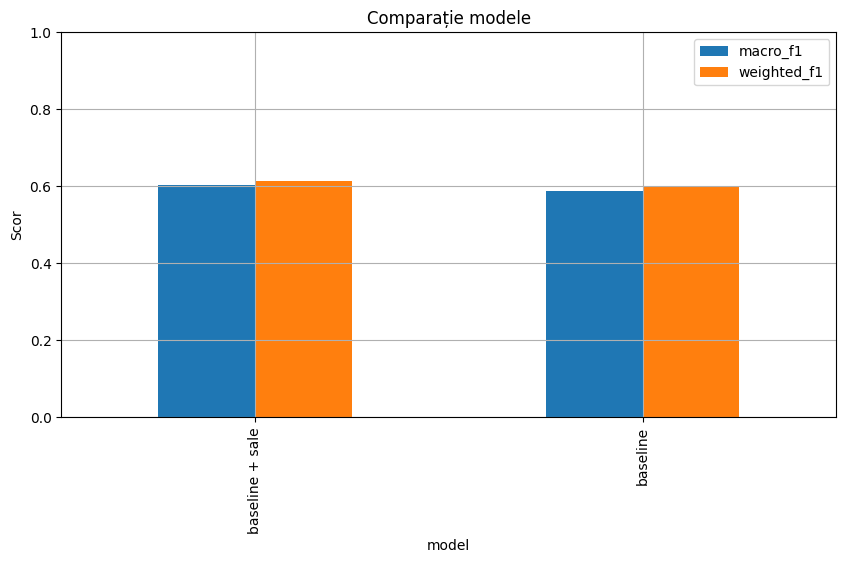

In [107]:
compare_df.set_index("model")[["macro_f1", "weighted_f1"]].plot(kind="bar")
plt.title("Comparație modele")
plt.ylabel("Scor")
plt.ylim(0, 1)
plt.show()

In [108]:
perm = permutation_importance(
    res_both["rf"],
    res_both["X_test"],
    res_both["y_test"],
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(perm.importances_mean, index=res_both["feature_cols"]).sort_values(ascending=False)

print("Top 20 permutation importance:")
display(perm_imp.head(20))

Top 20 permutation importance:


nr_dispozitii                 0.081746
An_depunere                   0.024339
LEGE_top_ALTELE               0.021076
Persoana_fizica_True          0.008951
Persoana_fizica_False         0.006570
Tip proprietate_Imobil        0.005820
Mai multe adrese_DA           0.005776
Tip proprietate_Teren         0.005071
lat                           0.004497
dist_km_centru                0.002513
Tip proprietate_Apartament    0.002381
Mai multe adrese_NU           0.002116
are_pdf_True                  0.001984
Executor_clean_False          0.001896
sector_4.0                    0.001675
sector_2.0                    0.001631
LEGE_top_Decret 223/1974      0.001499
pret_vanzare_relativ          0.001367
are_pdf_False                 0.001190
sector_6.0                    0.001014
dtype: float64

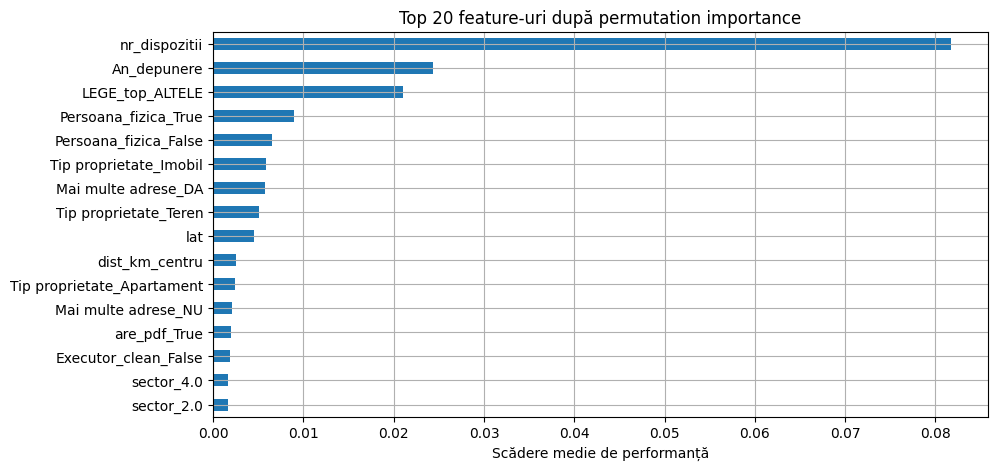

In [109]:
top_perm = perm_imp.head(16).sort_values(ascending=True)
top_perm.plot(kind="barh")
plt.title("Top 20 feature-uri după permutation importance")
plt.xlabel("Scădere medie de performanță")
plt.show()

In [110]:
features_interest = [
    f for f in perm_imp.index
    if ("pret_" in f) or ("nr_anunturi_" in f) or ("LEGE_top_" in f) or ("Executor_clean_" in f)
]

interest_imp_df = pd.DataFrame({
    "feature": features_interest,
    "permutation_importance": [perm_imp[f] for f in features_interest]
}).sort_values("permutation_importance", ascending=False)

display(interest_imp_df)

,feature,permutation_importance
0,LEGE_top_ALTELE,0.021076
1,Executor_clean_False,0.001896
2,LEGE_top_Decret 223/1974,0.001499
3,pret_vanzare_relativ,0.001367
4,LEGE_top_Lege 58/1974,0.000882
5,LEGE_top_Decret 152/1980,0.000485
6,LEGE_top_Decret 112/1989,0.000441
7,LEGE_top_HG 556/1990,0.000000
8,LEGE_top_Decret 218/1960,0.000000
9,LEGE_top_Decret 111/1951,-0.000044
